In [1]:
import os, glob, warnings, subprocess, sys
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


In [12]:
def find_dataset():
    """Locate the Global Weather Repository CSV under Kaggle's /kaggle/input tree,
    falling back to the working directory. Avoids hard-coding the exact dataset slug,
    which can change between Kaggle dataset versions."""
    candidates = glob.glob("/kaggle/input/**/*.csv", recursive=True)
    hits = [c for c in candidates if "weather" in c.lower()]
    return hits or glob.glob("*.csv")

matches = find_dataset()
print("Candidate files found:")
for m in matches:
    print(" -", m)

DATA_PATH = matches[0] if matches else "GlobalWeatherRepository.csv"
df = pd.read_csv("/kaggle/input/datasets/abubakar8367/internship-3/GlobalWeatherRepository.csv")
print(f"\nLoaded: {DATA_PATH}")
print(f"Shape: {df.shape}")
df.head(194)

Candidate files found:
 - /kaggle/input/datasets/abubakar8367/internship-3/GlobalWeatherRepository.csv

Loaded: /kaggle/input/datasets/abubakar8367/internship-3/GlobalWeatherRepository.csv
Shape: (148515, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.00,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.10,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.00,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.30,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.00,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,Vanuatu,Port Vila,-17.73,168.32,Pacific/Efate,1715849100,2024-05-16 19:45,25.0,77.0,Partly cloudy,8.1,13.0,120,ESE,1013.0,29.91,0.02,0.00,83,50,26.9,80.3,10.0,6.0,1.0,23.5,37.8,220.3,45.1,0.2,0.6,3.1,13.4,1,1,06:05 AM,05:21 PM,12:50 PM,No moonset,Waxing Gibbous,55
190,Venezuela,Caracas,10.50,-66.92,America/Caracas,1715849100,2024-05-16 04:45,26.0,78.8,Partly cloudy,2.2,3.6,10,N,1013.0,29.91,0.05,0.00,84,25,29.9,85.8,10.0,6.0,1.0,6.2,9.9,317.1,0.2,13.0,16.5,6.2,9.5,1,1,06:06 AM,06:42 PM,01:31 PM,01:28 AM,Waxing Gibbous,55
191,Vietnam,Hanoi,21.03,105.85,Asia/Bangkok,1715849100,2024-05-16 15:45,30.0,86.0,Partly cloudy,4.3,6.8,340,NNW,1011.0,29.85,0.03,0.00,62,75,32.5,90.4,10.0,6.0,6.0,5.0,8.1,560.8,197.4,14.7,27.2,72.5,82.8,4,10,05:19 AM,06:28 PM,12:27 PM,12:52 AM,Waxing Gibbous,55
192,Yemen,Sanaa,15.35,44.21,Asia/Aden,1715849100,2024-05-16 11:45,25.7,78.2,Patchy rain nearby,7.8,12.6,50,NE,1014.0,29.94,0.01,0.00,27,82,24.9,76.8,10.0,6.0,6.0,9.0,14.5,183.6,83.7,2.4,11.0,32.5,125.3,2,3,05:34 AM,06:25 PM,12:48 PM,12:57 AM,Waxing Gibbous,55


In [13]:
df.info()
print("\nNumeric feature count:", df.select_dtypes(include=[np.number]).shape[1])
print("Categorical feature count:", df.select_dtypes(include=["object"]).shape[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148515 entries, 0 to 148514
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       148515 non-null  object 
 1   location_name                 148515 non-null  object 
 2   latitude                      148515 non-null  float64
 3   longitude                     148515 non-null  float64
 4   timezone                      148515 non-null  object 
 5   last_updated_epoch            148515 non-null  int64  
 6   last_updated                  148515 non-null  object 
 7   temperature_celsius           148515 non-null  float64
 8   temperature_fahrenheit        148515 non-null  float64
 9   condition_text                148515 non-null  object 
 10  wind_mph                      148515 non-null  float64
 11  wind_kph                      148515 non-null  float64
 12  wind_degree                   148515 non-nul

In [14]:
# --- Robust column resolver -------------------------------------------------
# The Kaggle "Global Weather Repository" schema is fairly stable, but capitalization
# and minor naming differences appear across versions. This resolver maps logical
# names -> actual column names so every downstream cell is resilient to that drift.
cols_lower = {c.lower(): c for c in df.columns}

def get_col(*keys):
    for k in keys:
        if k in cols_lower:
            return cols_lower[k]
    for k in keys:
        for cl, orig in cols_lower.items():
            if k in cl:
                return orig
    return None

COL = dict(
    datetime    = get_col("last_updated"),
    epoch       = get_col("last_updated_epoch"),
    country     = get_col("country"),
    location    = get_col("location_name", "location"),
    region      = get_col("region"),
    lat         = get_col("latitude"),
    lon         = get_col("longitude"),
    temp_c      = get_col("temperature_celsius"),
    temp_f      = get_col("temperature_fahrenheit"),
    precip_mm   = get_col("precip_mm"),
    humidity    = get_col("humidity"),
    pressure_mb = get_col("pressure_mb"),
    wind_kph    = get_col("wind_kph"),
    uv          = get_col("uv_index"),
    cloud       = get_col("cloud"),
    condition   = get_col("condition_text"),
    pm25        = get_col("air_quality_pm2.5"),
    pm10        = get_col("air_quality_pm10"),
    co          = get_col("air_quality_carbon_monoxide"),
    o3          = get_col("air_quality_ozone"),
    no2         = get_col("air_quality_nitrogen_dioxide"),
    so2         = get_col("air_quality_sulphur_dioxide"),
)

print("Resolved column map:")
for k, v in COL.items():
    print(f"  {k:12s} -> {v}")

Resolved column map:
  datetime     -> last_updated
  epoch        -> last_updated_epoch
  country      -> country
  location     -> location_name
  region       -> None
  lat          -> latitude
  lon          -> longitude
  temp_c       -> temperature_celsius
  temp_f       -> temperature_fahrenheit
  precip_mm    -> precip_mm
  humidity     -> humidity
  pressure_mb  -> pressure_mb
  wind_kph     -> wind_kph
  uv           -> uv_index
  cloud        -> cloud
  condition    -> condition_text
  pm25         -> air_quality_PM2.5
  pm10         -> air_quality_PM10
  co           -> air_quality_Carbon_Monoxide
  o3           -> air_quality_Ozone
  no2          -> air_quality_Nitrogen_dioxide
  so2          -> air_quality_Sulphur_dioxide


In [16]:
## Section 1 — Data Cleaning & Preprocessing  *(Basic Assessment)*


In [17]:
# --- 1a. Missing value diagnostics ---
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report.missing_count > 0]
print(missing_report)

if len(missing_report):
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_report.index, y=missing_report["missing_pct"], color="#4C72B0")
    plt.xticks(rotation=75)
    plt.ylabel("% missing")
    plt.title("Missing Value Profile")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []
No missing values detected.


In [18]:
# --- 1b. Missing value treatment ---
dt = COL["datetime"]
df[dt] = pd.to_datetime(df[dt], errors="coerce")
df = df.dropna(subset=[dt])  # the time axis itself cannot be imputed safely

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Group-aware median imputation: weather is strongly location-dependent, so imputing
# with each location's own median is far more faithful than a single global median.
if COL["location"]:
    for c in numeric_cols:
        if df[c].isna().any():
            df[c] = df.groupby(COL["location"])[c].transform(lambda s: s.fillna(s.median()))

# Residual NaNs (e.g. a location with 100% missing on one feature) -> global fallback
for c in numeric_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())
for c in categorical_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])

print("Remaining missing values:", int(df.isna().sum().sum()))

Remaining missing values: 0


In [19]:
# --- 1c. Outlier detection (IQR method) on key numeric features ---
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

key_numeric = [c for c in [COL["temp_c"], COL["precip_mm"], COL["humidity"],
                            COL["pressure_mb"], COL["wind_kph"]] if c]

outlier_summary = {}
for c in key_numeric:
    lo, hi = iqr_bounds(df[c])
    n_out = int(((df[c] < lo) | (df[c] > hi)).sum())
    outlier_summary[c] = {"lower_bound": round(lo, 2), "upper_bound": round(hi, 2),
                           "n_outliers": n_out, "pct_outliers": round(n_out / len(df) * 100, 2)}

pd.DataFrame(outlier_summary).T

,lower_bound,upper_bound,n_outliers,pct_outliers
temperature_celsius,-1.85,45.75,2646.0,1.78
precip_mm,-0.03,0.05,29966.0,20.18
humidity,-1.50,138.50,0.0,0.00
pressure_mb,998.00,1030.00,4201.0,2.83
wind_kph,-11.15,34.85,2493.0,1.68


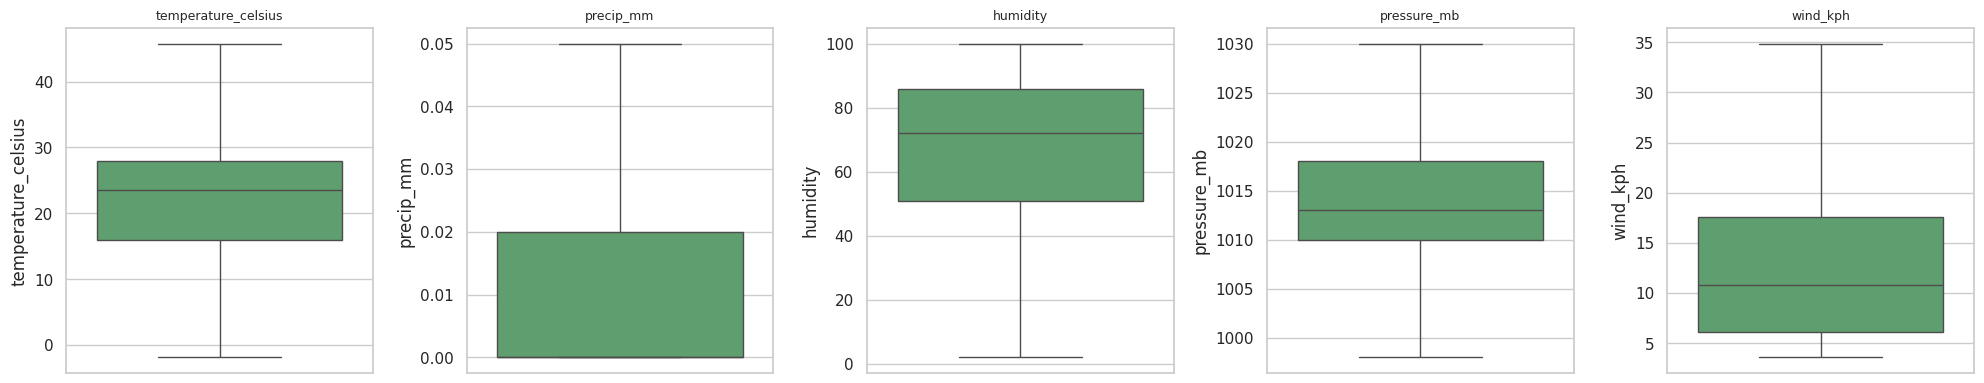

In [20]:
# --- 1d. Outlier treatment: winsorize (cap), don't drop ---
# Dropping rows would punch holes in the time series and break continuity for forecasting.
# Capping at the IQR fences preserves sample size while neutralizing extreme leverage points.
df_clean = df.copy()
for c in key_numeric:
    lo, hi = iqr_bounds(df[c])
    df_clean[c] = df_clean[c].clip(lower=lo, upper=hi)

fig, axes = plt.subplots(1, len(key_numeric), figsize=(4 * len(key_numeric), 4))
for ax, c in zip(axes, key_numeric):
    sns.boxplot(y=df_clean[c], ax=ax, color="#55A868")
    ax.set_title(c, fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
# --- 1e. Datetime feature engineering (uses last_updated, as the brief specifies) ---
df_clean["year"] = df_clean[dt].dt.year
df_clean["month"] = df_clean[dt].dt.month
df_clean["day"] = df_clean[dt].dt.day
df_clean["dayofweek"] = df_clean[dt].dt.dayofweek
df_clean["dayofyear"] = df_clean[dt].dt.dayofyear
df_clean["date"] = df_clean[dt].dt.date
df_clean["month_name"] = df_clean[dt].dt.month_name()

# --- 1f. Normalization (z-score) ---
# Kept in separate *_scaled columns so the originals remain available in natural units
# for plotting and stakeholder-facing interpretation.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(df_clean[key_numeric])
df_clean[[f"{c}_scaled" for c in key_numeric]] = scaled

df_clean[[dt] + key_numeric + [f"{c}_scaled" for c in key_numeric]].head()

,last_updated,temperature_celsius,precip_mm,humidity,pressure_mb,wind_kph,temperature_celsius_scaled,precip_mm_scaled,humidity_scaled,pressure_mb_scaled,wind_kph_scaled
0,2024-05-16 13:15:00,26.6,0.00,24,1012.0,13.3,0.563419,-0.630772,-1.807628,-0.314236,0.075745
1,2024-05-16 10:45:00,19.0,0.05,94,1012.0,11.2,-0.258589,1.796803,1.144338,-0.314236,-0.186936
2,2024-05-16 09:45:00,23.0,0.00,29,1011.0,15.1,0.174047,-0.630772,-1.596773,-0.467752,0.300899
3,2024-05-16 10:45:00,6.3,0.05,61,1007.0,11.9,-1.632210,1.796803,-0.247303,-1.081816,-0.099376
4,2024-05-16 09:45:00,26.0,0.00,89,1011.0,13.0,0.498524,-0.630772,0.933483,-0.467752,0.038219


In [23]:
## Section 2 — Exploratory Data Analysis  *(Basic Assessment)*


In [24]:
# --- 2a. Descriptive statistics ---
df_clean[key_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_celsius,148515.0,21.390825,9.245673,-1.85,16.0,23.6,27.90,45.75
precip_mm,148515.0,0.012992,0.020597,0.00,0.0,0.0,0.02,0.05
humidity,148515.0,66.864297,23.713091,2.00,51.0,72.0,86.00,100.00
pressure_mb,148515.0,1014.046925,6.514001,998.00,1010.0,1013.0,1018.00,1030.00
wind_kph,148515.0,12.694460,7.994532,3.60,6.1,10.8,17.60,34.85


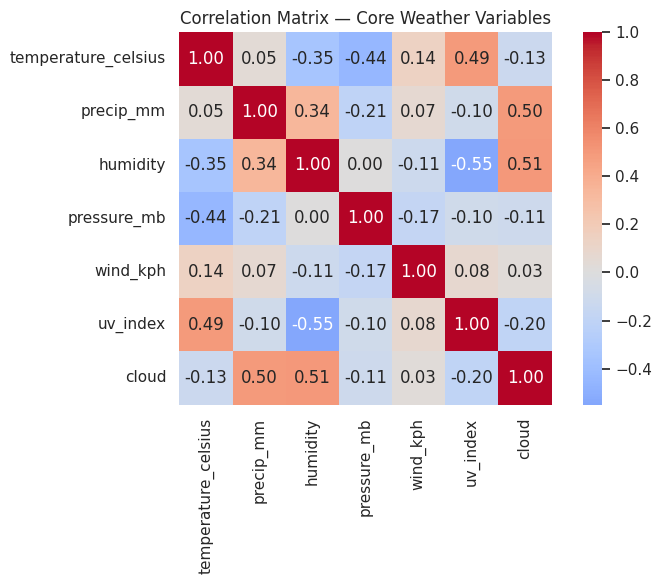

In [25]:
# --- 2b. Correlation matrix ---
corr_cols = [c for c in [COL["temp_c"], COL["precip_mm"], COL["humidity"], COL["pressure_mb"],
                          COL["wind_kph"], COL["uv"], COL["cloud"]] if c]
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix — Core Weather Variables")
plt.tight_layout()
plt.show()

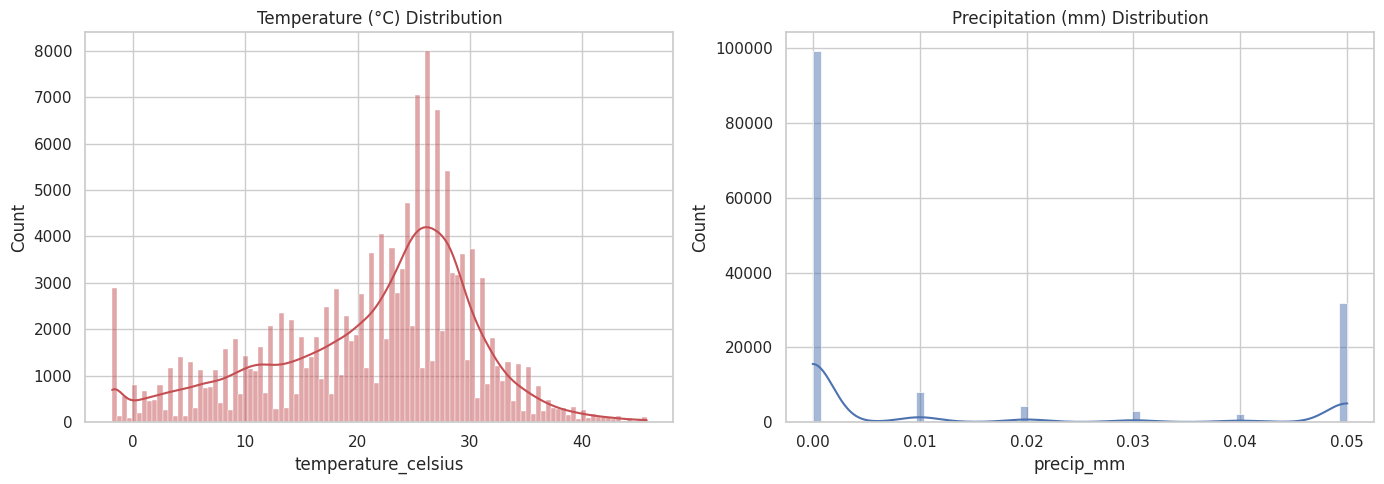

In [26]:
# --- 2c. Temperature & precipitation distributions ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean[COL["temp_c"]], kde=True, ax=axes[0], color="#C44E52")
axes[0].set_title("Temperature (°C) Distribution")
sns.histplot(df_clean[COL["precip_mm"]], kde=True, ax=axes[1], color="#4C72B0")
axes[1].set_title("Precipitation (mm) Distribution")
plt.tight_layout()
plt.show()

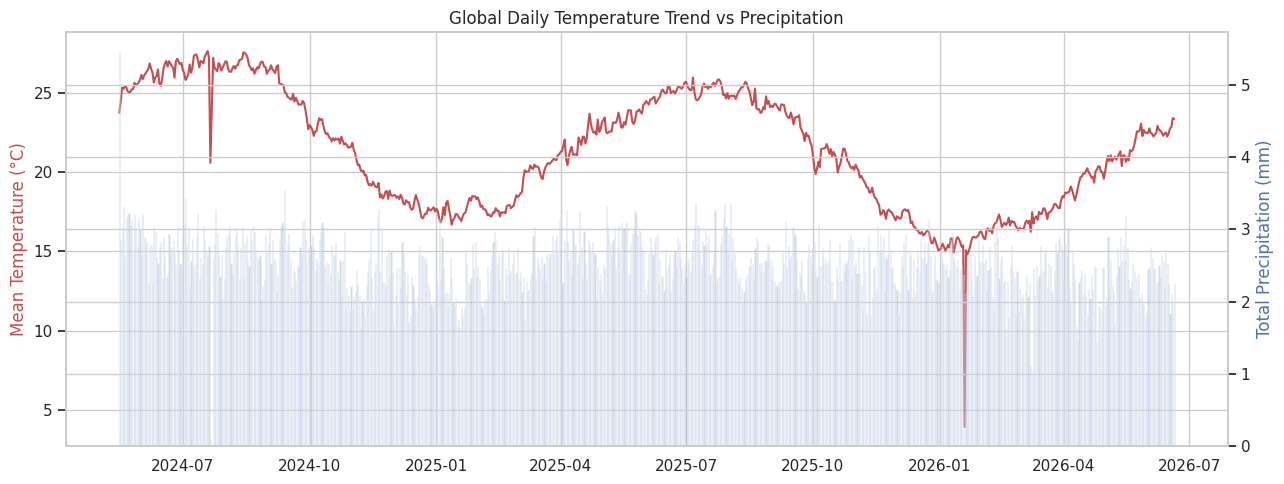

In [27]:
# --- 2d. Global daily trend: temperature vs precipitation ---
daily_global = df_clean.groupby("date").agg(
    temp_mean=(COL["temp_c"], "mean"),
    precip_sum=(COL["precip_mm"], "sum"),
).reset_index()
daily_global["date"] = pd.to_datetime(daily_global["date"])

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()
ax1.plot(daily_global["date"], daily_global["temp_mean"], color="#C44E52", label="Mean Temp (°C)")
ax2.bar(daily_global["date"], daily_global["precip_sum"], color="#4C72B0", alpha=0.3, label="Total Precip (mm)")
ax1.set_ylabel("Mean Temperature (°C)", color="#C44E52")
ax2.set_ylabel("Total Precipitation (mm)", color="#4C72B0")
plt.title("Global Daily Temperature Trend vs Precipitation")
fig.tight_layout()
plt.show()

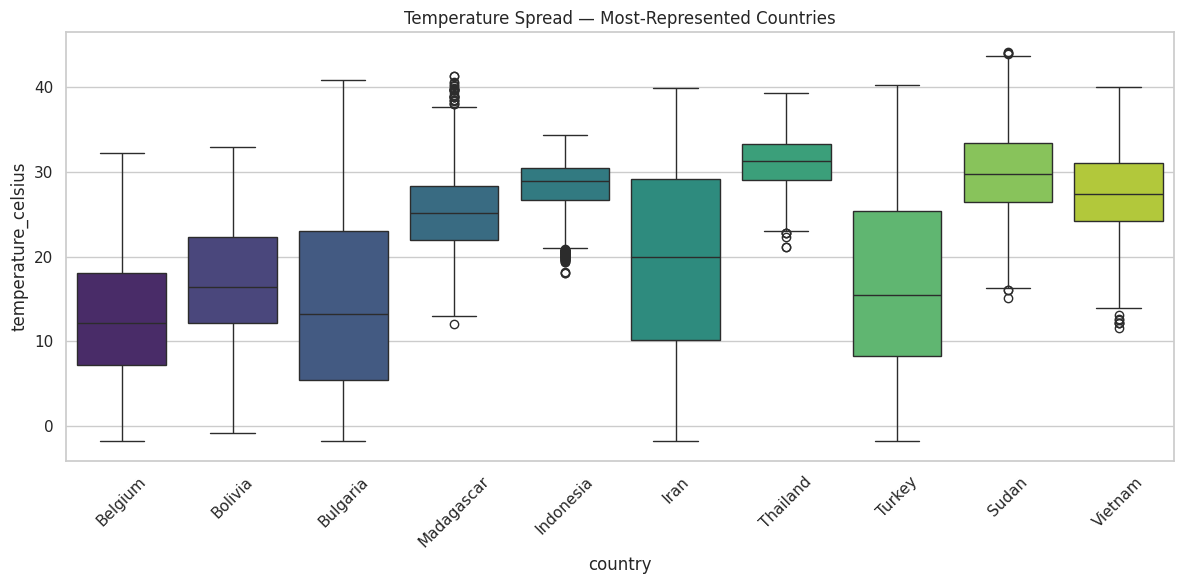

In [28]:
# --- 2e. Temperature spread across most-represented countries ---
top_countries = df_clean[COL["country"]].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[df_clean[COL["country"]].isin(top_countries)],
            x=COL["country"], y=COL["temp_c"], palette="viridis")
plt.xticks(rotation=45)
plt.title("Temperature Spread — Most-Represented Countries")
plt.tight_layout()
plt.show()

In [29]:
## Section 3 — Basic Forecasting Model 

In [30]:
# --- 3a. Supervised time-series framing (lag + rolling window features) ---
ts = daily_global.sort_values("date").reset_index(drop=True)

def add_lag_features(frame, col, lags=(1, 2, 3, 7), roll_windows=(3, 7)):
    frame = frame.copy()
    for l in lags:
        frame[f"{col}_lag{l}"] = frame[col].shift(l)
    for w in roll_windows:
        frame[f"{col}_roll{w}_mean"] = frame[col].shift(1).rolling(w).mean()
        frame[f"{col}_roll{w}_std"] = frame[col].shift(1).rolling(w).std()
    return frame

ts_feat = add_lag_features(ts, "temp_mean").dropna().reset_index(drop=True)
ts_feat.head()

,date,temp_mean,precip_sum,temp_mean_lag1,temp_mean_lag2,temp_mean_lag3,temp_mean_lag7,temp_mean_roll3_mean,temp_mean_roll3_std,temp_mean_roll7_mean,temp_mean_roll7_std
0,2024-05-23,25.066154,3.23,25.123077,25.383077,25.430769,23.767196,25.312308,0.165605,24.968783,0.627235
1,2024-05-24,25.088718,3.06,25.066154,25.123077,25.383077,24.451648,25.190769,0.168958,25.154348,0.337929
2,2024-05-25,25.249744,3.14,25.088718,25.066154,25.123077,25.355610,25.092650,0.028664,25.245358,0.151501
3,2024-05-26,25.254359,2.69,25.249744,25.088718,25.066154,25.270103,25.134872,0.100120,25.230235,0.143746
4,2024-05-27,25.660513,3.22,25.254359,25.249744,25.088718,25.430769,25.197607,0.094329,25.227985,0.143140


In [31]:
# --- 3b. Time-based train/test split (never shuffle a time series!) ---
split_idx = int(len(ts_feat) * 0.8)
train, test = ts_feat.iloc[:split_idx], ts_feat.iloc[split_idx:]

feature_cols = [c for c in ts_feat.columns if c not in ["date", "temp_mean", "precip_sum"]]
X_train, y_train = train[feature_cols], train["temp_mean"]
X_test, y_test = test[feature_cols], test["temp_mean"]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (606, 8)  |  Test: (152, 8)


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, name, store=None):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-6, y_true))) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"{name:28s} | MAE: {mae:6.3f}  RMSE: {rmse:6.3f}  MAPE: {mape:6.2f}%  R2: {r2:6.3f}")
    record = dict(model=name, MAE=mae, RMSE=rmse, MAPE=mape, R2=r2)
    if store is not None:
        store.append(record)
    return record

results = []

# Baseline: naive persistence (tomorrow = today)
baseline_pred = test["temp_mean_lag1"].values
evaluate(y_test, baseline_pred, "Naive (t-1)", results)

# Basic model: Linear Regression on lag/rolling features
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
evaluate(y_test, lr_pred, "Linear Regression", results)

Naive (t-1)                  | MAE:  0.313  RMSE:  0.959  MAPE:   1.76%  R2:  0.842
Linear Regression            | MAE:  0.303  RMSE:  0.521  MAPE:   1.65%  R2:  0.953


{'model': 'Linear Regression',
 'MAE': 0.30309205652075816,
 'RMSE': np.float64(0.5210388948896868),
 'MAPE': np.float64(1.6509260270602868),
 'R2': 0.9532557898870047}

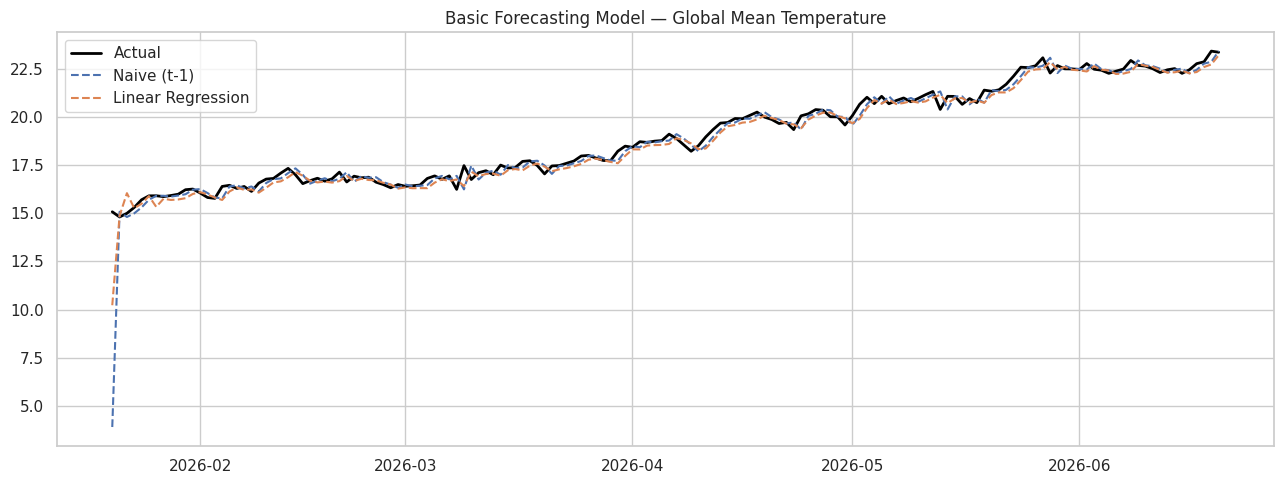

In [33]:
plt.figure(figsize=(13, 5))
plt.plot(test["date"], y_test, label="Actual", color="black", linewidth=2)
plt.plot(test["date"], baseline_pred, label="Naive (t-1)", linestyle="--")
plt.plot(test["date"], lr_pred, label="Linear Regression", linestyle="--")
plt.legend()
plt.title("Basic Forecasting Model — Global Mean Temperature")
plt.tight_layout()
plt.show()

In [34]:
## Section 4 — Advanced EDA: Anomaly Detection  *(Advanced Assessment)*

In [35]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

anomaly_features = [c for c in [COL["temp_c"], COL["precip_mm"], COL["humidity"],
                                 COL["pressure_mb"], COL["wind_kph"]] if c]
X_anom = df_clean[anomaly_features].fillna(df_clean[anomaly_features].median())

# Multivariate detector: catches joint outliers a single-feature rule would miss
iso = IsolationForest(n_estimators=300, contamination=0.02, random_state=RANDOM_STATE, n_jobs=-1)
df_clean["anomaly_iforest"] = iso.fit_predict(X_anom)  # -1 = anomaly

# Simple univariate cross-check for interpretability
z = np.abs(zscore(X_anom))
df_clean["anomaly_zscore"] = (z > 3).any(axis=1)

n_iforest = int((df_clean["anomaly_iforest"] == -1).sum())
n_zscore = int(df_clean["anomaly_zscore"].sum())
print(f"Isolation Forest flagged: {n_iforest} rows ({n_iforest/len(df_clean):.2%})")
print(f"Z-score (>3 sigma) flagged: {n_zscore} rows ({n_zscore/len(df_clean):.2%})")

Isolation Forest flagged: 2971 rows (2.00%)
Z-score (>3 sigma) flagged: 0 rows (0.00%)


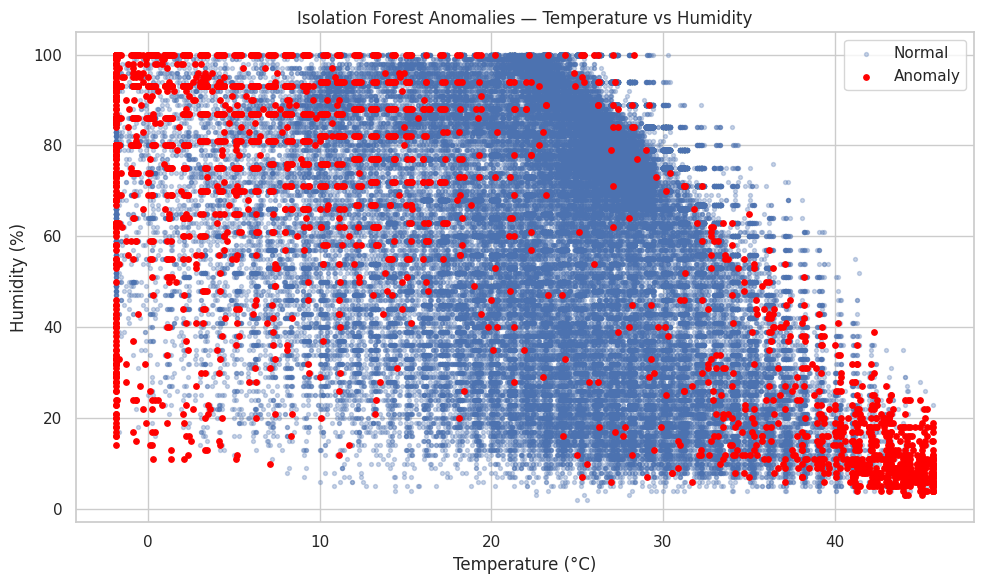

In [36]:
normal = df_clean[df_clean["anomaly_iforest"] == 1]
anom = df_clean[df_clean["anomaly_iforest"] == -1]

plt.figure(figsize=(10, 6))
plt.scatter(normal[COL["temp_c"]], normal[COL["humidity"]], s=8, alpha=0.3, label="Normal")
plt.scatter(anom[COL["temp_c"]], anom[COL["humidity"]], s=15, color="red", label="Anomaly")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.title("Isolation Forest Anomalies — Temperature vs Humidity")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
### Section 5 — Multi-Model Forecasting + Ensemble  *(Advanced Assessment)*
##Builds SARIMA, Prophet, and XGBoost on the same held-out date range, then combines them
##into an inverse-RMSE-weighted ensemble.##

In [38]:
# Common test window (by date) so every model is judged on identical ground truth
test_dates = test["date"].values
y_full = ts.set_index("date")["temp_mean"]
y_train_full = y_full.loc[y_full.index < test_dates[0]]
y_test_full = y_full.loc[y_full.index.isin(test_dates)]
print(f"Train window: {y_train_full.index.min().date()} -> {y_train_full.index.max().date()}")
print(f"Test window:  {y_test_full.index.min().date()} -> {y_test_full.index.max().date()}")

Train window: 2024-05-16 -> 2026-01-19
Test window:  2026-01-20 -> 2026-06-20


ADF Statistic: 1.0735  |  p-value: 0.9950
=> Non-stationary — differencing needed


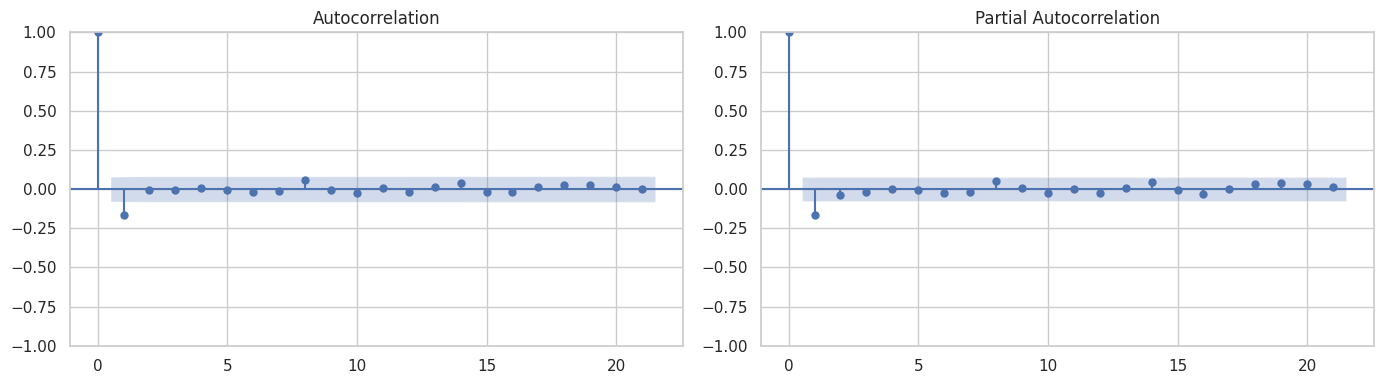

In [40]:
# --- 5a-i. Stationarity check (justifies the differencing order instead of guessing) ---
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

adf_result = adfuller(y_train_full.dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}  |  p-value: {adf_result[1]:.4f}")
print("=>", "Stationary" if adf_result[1] < 0.05 else "Non-stationary — differencing needed")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_train_full.diff().dropna(), ax=axes[0], lags=21)
plot_pacf(y_train_full.diff().dropna(), ax=axes[1], lags=21)
plt.tight_layout()
plt.show()

In [43]:
# --- 5a. SARIMA (captures trend + weekly seasonality) ---
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(y_train_full, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                  enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=len(y_test_full))
sarima_pred.index = y_test_full.index

evaluate(y_test_full, sarima_pred, "SARIMA(1,1,1)(1,1,1,7)", results)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SARIMA(1,1,1)(1,1,1,7)       | MAE: 18.716  RMSE: 20.296  MAPE:  94.82%  R2: -69.925


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


{'model': 'SARIMA(1,1,1)(1,1,1,7)',
 'MAE': 18.716404604667606,
 'RMSE': np.float64(20.295759156787895),
 'MAPE': np.float64(94.82115472320132),
 'R2': -69.92480306649823}

In [44]:
# --- 5b. Prophet (handles holidays/seasonality + trend changepoints automatically) ---
try:
    from prophet import Prophet
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "prophet"])
    from prophet import Prophet

prophet_train = y_train_full.reset_index().rename(columns={"date": "ds", "temp_mean": "y"})
m = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
m.fit(prophet_train)

future = pd.DataFrame({"ds": y_test_full.index})
fcst = m.predict(future)
prophet_pred = pd.Series(fcst["yhat"].values, index=y_test_full.index)

evaluate(y_test_full, prophet_pred, "Prophet", results)

08:35:49 - cmdstanpy - INFO - Chain [1] start processing
08:35:49 - cmdstanpy - INFO - Chain [1] done processing


Prophet                      | MAE: 10.523  RMSE: 11.902  MAPE:  52.54%  R2: -23.390


{'model': 'Prophet',
 'MAE': 10.522804538821644,
 'RMSE': np.float64(11.901787087877903),
 'MAPE': np.float64(52.53826483893948),
 'R2': -23.390005098141618}

In [45]:
# --- 5c. XGBoost (gradient-boosted trees on lag/rolling/calendar features) ---
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.03,
                    subsample=0.8, colsample_bytree=0.8,
                    random_state=RANDOM_STATE, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_pred = pd.Series(xgb.predict(X_test), index=test["date"].values)

evaluate(y_test_full, xgb_pred.reindex(y_test_full.index).values, "XGBoost", results)

XGBoost                      | MAE:  0.315  RMSE:  0.432  MAPE:   1.72%  R2:  0.968


{'model': 'XGBoost',
 'MAE': 0.3148576028444966,
 'RMSE': np.float64(0.43209611320189517),
 'MAPE': np.float64(1.716865107927279),
 'R2': 0.9678524221372363}

In [46]:
# --- 5d. Ensemble: inverse-RMSE weighted average across the 3 independent models ---
pred_frame = pd.DataFrame({
    "actual": y_test_full,
    "sarima": sarima_pred,
    "prophet": prophet_pred,
    "xgboost": xgb_pred.reindex(y_test_full.index),
}).dropna()

model_cols = ["sarima", "prophet", "xgboost"]
rmses = {c: np.sqrt(mean_squared_error(pred_frame["actual"], pred_frame[c])) for c in model_cols}
inv_w = {c: 1 / r for c, r in rmses.items()}
total_w = sum(inv_w.values())
weights = {c: w / total_w for c, w in inv_w.items()}
print("Ensemble weights (inverse-RMSE):", {k: round(v, 3) for k, v in weights.items()})

pred_frame["ensemble"] = sum(pred_frame[c] * weights[c] for c in model_cols)
evaluate(pred_frame["actual"], pred_frame["ensemble"], "Ensemble (weighted avg)", results)

results_df = pd.DataFrame(results).set_index("model").sort_values("RMSE")
results_df

Ensemble weights (inverse-RMSE): {'sarima': np.float64(0.02), 'prophet': np.float64(0.034), 'xgboost': np.float64(0.946)}
Ensemble (weighted avg)      | MAE:  0.903  RMSE:  1.011  MAPE:   4.63%  R2:  0.824


,MAE,RMSE,MAPE,R2
model,,,,
XGBoost,0.314858,0.432096,1.716865,0.967852
Linear Regression,0.303092,0.521039,1.650926,0.953256
Naive (t-1),0.313374,0.959028,1.759415,0.841638
Ensemble (weighted avg),0.902895,1.010979,4.627322,0.824017
Prophet,10.522805,11.901787,52.538265,-23.390005
"SARIMA(1,1,1)(1,1,1,7)",18.716405,20.295759,94.821155,-69.924803
"SARIMA(1,1,1)(1,1,1,7)",18.716405,20.295759,94.821155,-69.924803


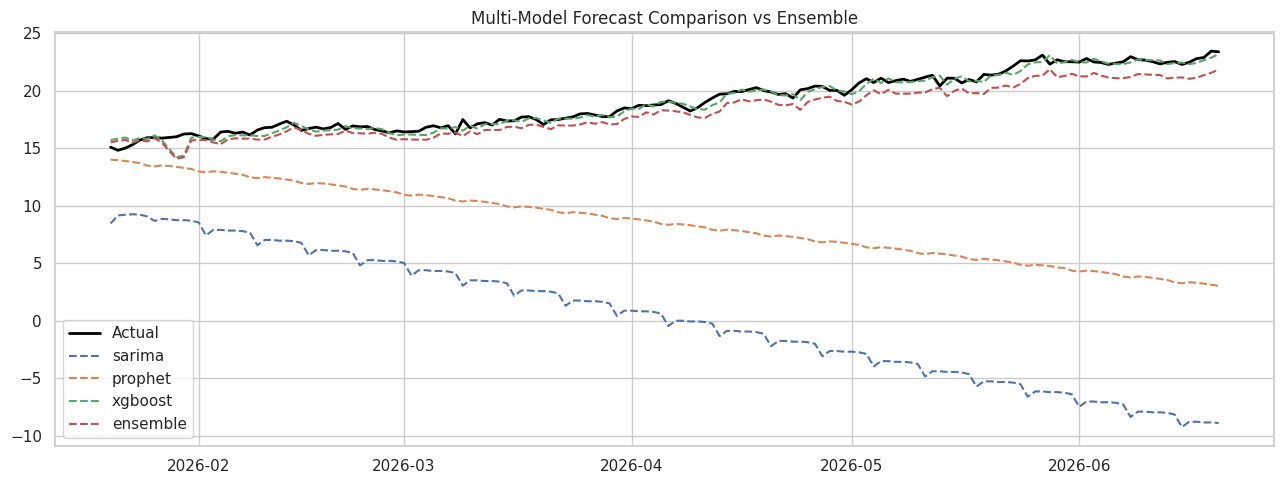

In [47]:
plt.figure(figsize=(13, 5))
plt.plot(pred_frame.index, pred_frame["actual"], color="black", linewidth=2, label="Actual")
for c in model_cols + ["ensemble"]:
    plt.plot(pred_frame.index, pred_frame[c], linestyle="--", label=c)
plt.legend()
plt.title("Multi-Model Forecast Comparison vs Ensemble")
plt.tight_layout()
plt.show()

In [48]:
## Section 6 — Unique Analyses  *(Advanced Assessment)*
##Climate patterns, environmental impact, feature importance, spatial analysis, geographic patterns.

#> **Coverage caveat:** this dataset is a rolling window of recent daily snapshots rather than a
#> multi-decade archive, so "climate" patterns below describe *seasonal/regional structure within
#> the available window*, not multi-year climatology. State this explicitly in your report.

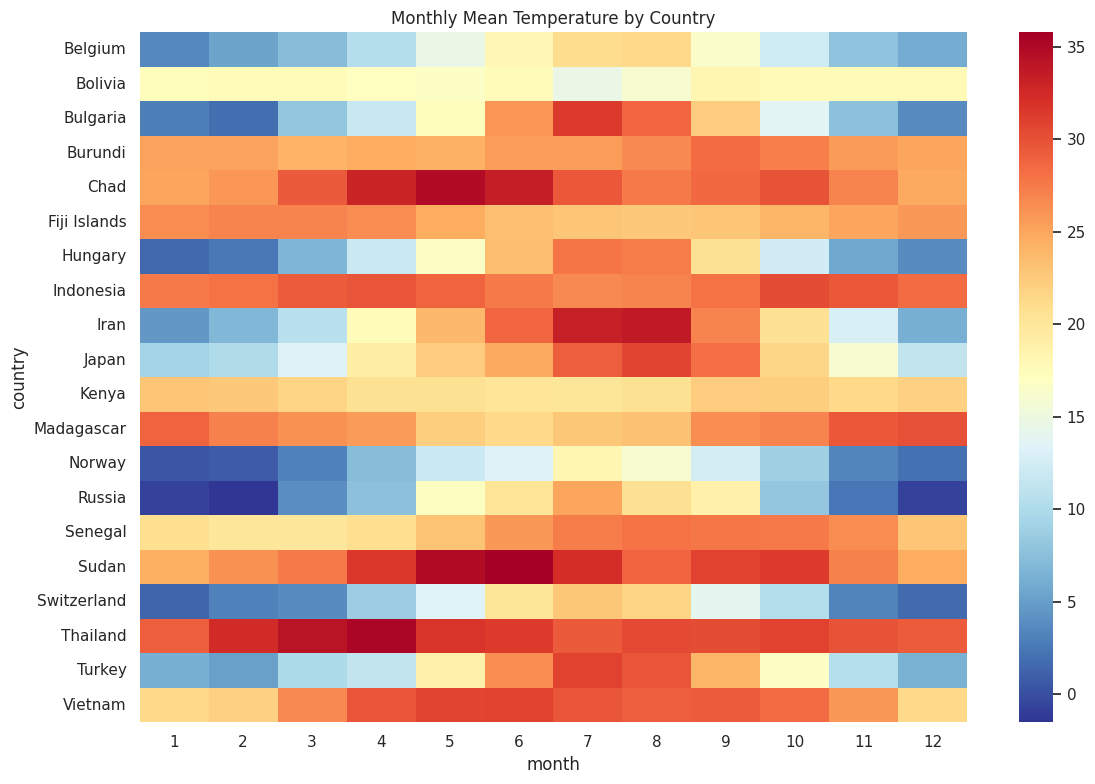

In [49]:
# --- 6a. Climate Analysis: monthly temperature pattern by country ---
climate = df_clean.groupby([COL["country"], "month"])[COL["temp_c"]].mean().reset_index()
pivot_climate = climate.pivot(index=COL["country"], columns="month", values=COL["temp_c"])

top20 = df_clean[COL["country"]].value_counts().head(20).index
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_climate.loc[pivot_climate.index.intersection(top20)], cmap="RdYlBu_r")
plt.title("Monthly Mean Temperature by Country")
plt.tight_layout()
plt.show()

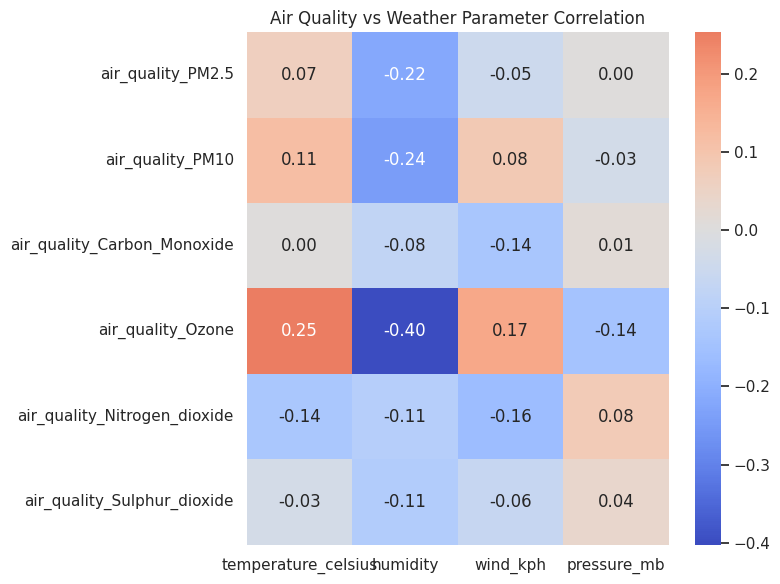

In [50]:
# --- 6b. Environmental Impact: air quality vs weather correlation ---
aqi_cols = [c for c in [COL.get("pm25"), COL.get("pm10"), COL.get("co"),
                        COL.get("o3"), COL.get("no2"), COL.get("so2")] if c]
weather_cols = [c for c in [COL["temp_c"], COL["humidity"], COL["wind_kph"], COL["pressure_mb"]] if c]

if aqi_cols:
    env_corr = df_clean[aqi_cols + weather_cols].corr().loc[aqi_cols, weather_cols]
    plt.figure(figsize=(8, 6))
    sns.heatmap(env_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Air Quality vs Weather Parameter Correlation")
    plt.tight_layout()
    plt.show()
else:
    print("Air-quality columns not found under expected names; inspect df.columns and extend COL.")

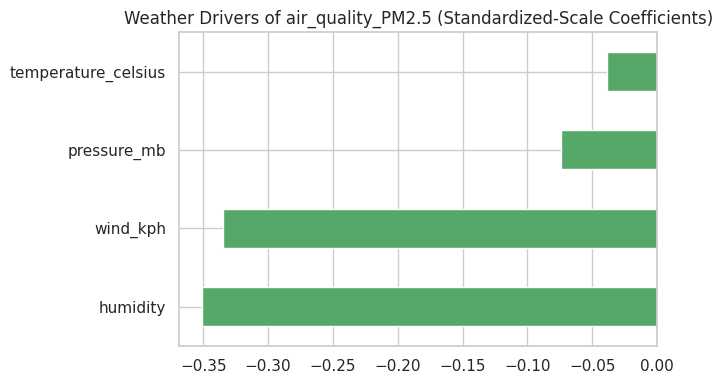

In [51]:
# --- 6b (cont.) Which weather variables most strongly drive a given pollutant? ---
if aqi_cols:
    target = aqi_cols[0]
    X_env = df_clean[weather_cols].fillna(df_clean[weather_cols].median())
    y_env = df_clean[target].fillna(df_clean[target].median())
    lr_env = LinearRegression().fit(X_env, y_env)
    coef_series = pd.Series(lr_env.coef_, index=weather_cols).sort_values()
    coef_series.plot(kind="barh", color="#55A868", figsize=(7, 4))
    plt.title(f"Weather Drivers of {target} (Standardized-Scale Coefficients)")
    plt.tight_layout()
    plt.show()

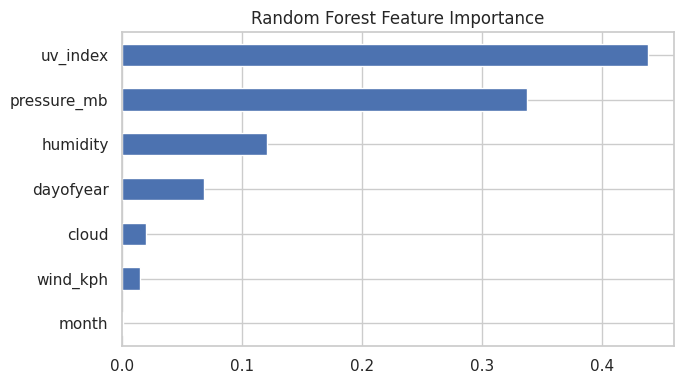

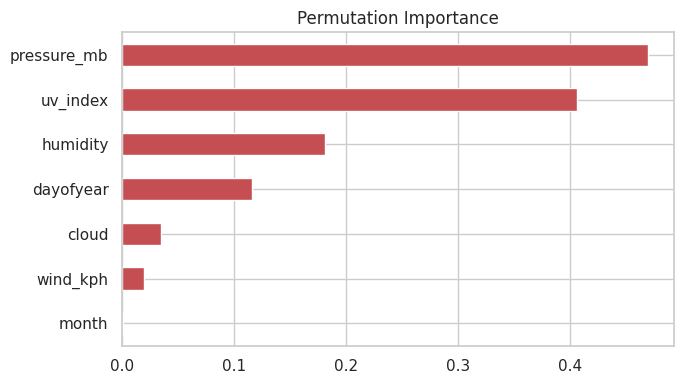

In [52]:
# --- 6c. Feature Importance: which weather variables best explain temperature? ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

fi_features = [c for c in [COL["humidity"], COL["pressure_mb"], COL["wind_kph"], COL["cloud"],
                            COL["uv"], "month", "dayofyear"] if c and c in df_clean.columns]
X_fi = df_clean[fi_features].fillna(df_clean[fi_features].median())
y_fi = df_clean[COL["temp_c"]]

rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_fi, y_fi)

imp_series = pd.Series(rf.feature_importances_, index=fi_features).sort_values()
imp_series.plot(kind="barh", figsize=(7, 4), color="#4C72B0", title="Random Forest Feature Importance")
plt.tight_layout()
plt.show()

# Permutation importance: model-agnostic, more reliable when features are correlated
perm = permutation_importance(rf, X_fi, y_fi, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_series = pd.Series(perm.importances_mean, index=fi_features).sort_values()
perm_series.plot(kind="barh", figsize=(7, 4), color="#C44E52", title="Permutation Importance")
plt.tight_layout()
plt.show()

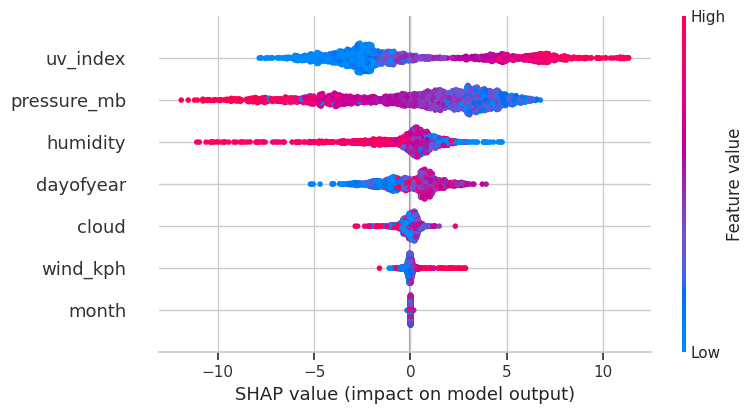

In [54]:
# --- 6c (cont.) SHAP: exact additive feature attributions per prediction ---
try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])
    import shap

explainer = shap.TreeExplainer(rf)
sample = X_fi.sample(min(2000, len(X_fi)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, show=True)

In [55]:
# --- 6d. Spatial Analysis: latest global temperature snapshot ---
import plotly.express as px

snapshot = df_clean.sort_values(dt).groupby(COL["location"]).tail(1)
fig = px.scatter_geo(snapshot, lat=COL["lat"], lon=COL["lon"],
                      color=COL["temp_c"], hover_name=COL["location"],
                      color_continuous_scale="RdYlBu_r",
                      title="Latest Temperature Snapshot — Global Spatial Distribution")
fig.update_layout(geo=dict(showland=True, landcolor="rgb(243,243,243)"))
fig.show()

In [56]:
# --- 6d (cont.) Folium heatmap — interactive, exports to standalone HTML for the report ---
import folium
from folium.plugins import HeatMap

fmap = folium.Map(location=[20, 0], zoom_start=2, tiles="cartodbpositron")
heat_data = snapshot[[COL["lat"], COL["lon"], COL["temp_c"]]].dropna().values.tolist()
HeatMap(heat_data, radius=15, blur=20).add_to(fmap)
fmap.save("temperature_heatmap.html")
fmap

24 countries not mapped — add these to COUNTRY_TO_CONTINENT manually:
['Bélgica', "Cote d'Ivoire", 'Democratic Republic of Congo', 'Estonie', 'Inde', 'Jemen', 'Komoren', 'Kyrghyzstan', "Lao People's Democratic Republic", 'Letonia', 'Malásia', 'Marrocos', 'Mexique', 'Polônia', 'Saint-Vincent-et-les-Grenadines', 'Saudi Arabien', 'Swaziland', 'Südkorea', 'Turkménistan', 'Гватемала', 'Польша', 'Турция', 'كولومبيا', '火鸡']


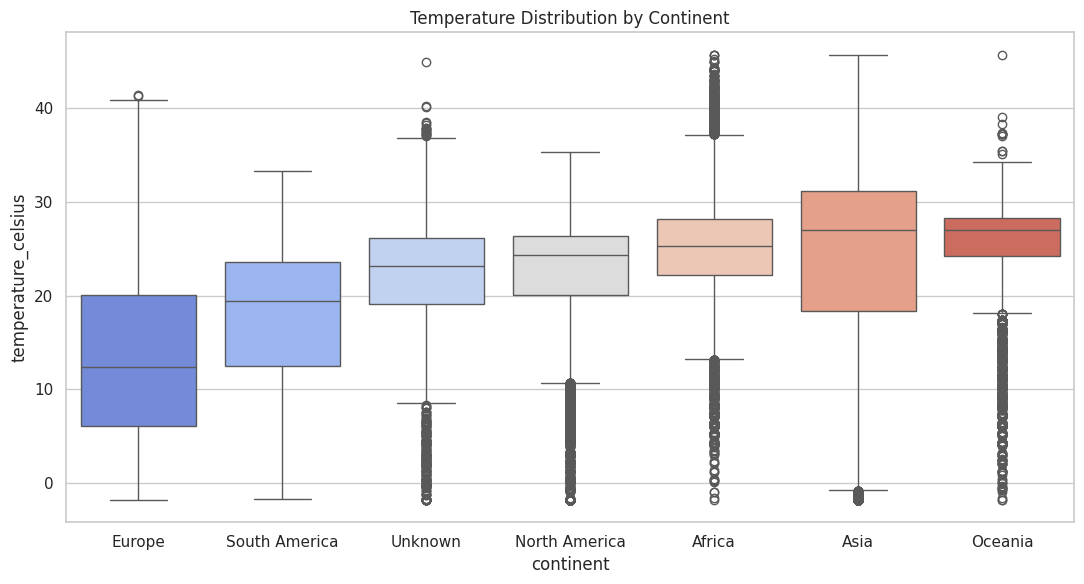

In [58]:
# --- 6e. Geographical Patterns: continent-level comparison (no external package needed) ---
# Static lookup avoids depending on pip install at runtime (Kaggle kernels often have
# internet access disabled by default, which is what caused the CalledProcessError above).
COUNTRY_TO_CONTINENT = {
    # Africa
    "Algeria": "Africa", "Angola": "Africa", "Benin": "Africa", "Botswana": "Africa",
    "Burkina Faso": "Africa", "Burundi": "Africa", "Cameroon": "Africa", "Cape Verde": "Africa",
    "Central African Republic": "Africa", "Chad": "Africa", "Comoros": "Africa",
    "Democratic Republic of the Congo": "Africa", "Republic of the Congo": "Africa",
    "Djibouti": "Africa", "Egypt": "Africa", "Equatorial Guinea": "Africa", "Eritrea": "Africa",
    "Eswatini": "Africa", "Ethiopia": "Africa", "Gabon": "Africa", "Gambia": "Africa",
    "Ghana": "Africa", "Guinea": "Africa", "Guinea-Bissau": "Africa", "Ivory Coast": "Africa",
    "Kenya": "Africa", "Lesotho": "Africa", "Liberia": "Africa", "Libya": "Africa",
    "Madagascar": "Africa", "Malawi": "Africa", "Mali": "Africa", "Mauritania": "Africa",
    "Mauritius": "Africa", "Morocco": "Africa", "Mozambique": "Africa", "Namibia": "Africa",
    "Niger": "Africa", "Nigeria": "Africa", "Rwanda": "Africa", "Sao Tome and Principe": "Africa",
    "Senegal": "Africa", "Seychelles": "Africa", "Sierra Leone": "Africa", "Somalia": "Africa",
    "South Africa": "Africa", "South Sudan": "Africa", "Sudan": "Africa", "Tanzania": "Africa",
    "Togo": "Africa", "Tunisia": "Africa", "Uganda": "Africa", "Zambia": "Africa",
    "Zimbabwe": "Africa",
    # Asia
    "Afghanistan": "Asia", "Armenia": "Asia", "Azerbaijan": "Asia", "Bahrain": "Asia",
    "Bangladesh": "Asia", "Bhutan": "Asia", "Brunei": "Asia", "Cambodia": "Asia", "China": "Asia",
    "Cyprus": "Asia", "Georgia": "Asia", "India": "Asia", "Indonesia": "Asia", "Iran": "Asia",
    "Iraq": "Asia", "Israel": "Asia", "Japan": "Asia", "Jordan": "Asia", "Kazakhstan": "Asia",
    "Kuwait": "Asia", "Kyrgyzstan": "Asia", "Laos": "Asia", "Lebanon": "Asia", "Malaysia": "Asia",
    "Maldives": "Asia", "Mongolia": "Asia", "Myanmar": "Asia", "Nepal": "Asia",
    "North Korea": "Asia", "Oman": "Asia", "Pakistan": "Asia", "Palestine": "Asia",
    "Philippines": "Asia", "Qatar": "Asia", "Saudi Arabia": "Asia", "Singapore": "Asia",
    "South Korea": "Asia", "Sri Lanka": "Asia", "Syria": "Asia", "Taiwan": "Asia",
    "Tajikistan": "Asia", "Thailand": "Asia", "Timor-Leste": "Asia", "Turkey": "Asia",
    "Turkmenistan": "Asia", "United Arab Emirates": "Asia", "Uzbekistan": "Asia",
    "Vietnam": "Asia", "Yemen": "Asia",
    # Europe
    "Albania": "Europe", "Andorra": "Europe", "Austria": "Europe", "Belarus": "Europe",
    "Belgium": "Europe", "Bosnia and Herzegovina": "Europe", "Bulgaria": "Europe",
    "Croatia": "Europe", "Czech Republic": "Europe", "Czechia": "Europe", "Denmark": "Europe",
    "Estonia": "Europe", "Finland": "Europe", "France": "Europe", "Germany": "Europe",
    "Greece": "Europe", "Hungary": "Europe", "Iceland": "Europe", "Ireland": "Europe",
    "Italy": "Europe", "Kosovo": "Europe", "Latvia": "Europe", "Liechtenstein": "Europe",
    "Lithuania": "Europe", "Luxembourg": "Europe", "Malta": "Europe", "Moldova": "Europe",
    "Monaco": "Europe", "Montenegro": "Europe", "Netherlands": "Europe",
    "North Macedonia": "Europe", "Norway": "Europe", "Poland": "Europe", "Portugal": "Europe",
    "Romania": "Europe", "Russia": "Europe", "San Marino": "Europe", "Serbia": "Europe",
    "Slovakia": "Europe", "Slovenia": "Europe", "Spain": "Europe", "Sweden": "Europe",
    "Switzerland": "Europe", "Ukraine": "Europe", "United Kingdom": "Europe",
    "Vatican City": "Europe",
    # North America
    "Antigua and Barbuda": "North America", "Bahamas": "North America",
    "Barbados": "North America", "Belize": "North America", "Canada": "North America",
    "Costa Rica": "North America", "Cuba": "North America", "Dominica": "North America",
    "Dominican Republic": "North America", "El Salvador": "North America",
    "Grenada": "North America", "Guatemala": "North America", "Haiti": "North America",
    "Honduras": "North America", "Jamaica": "North America", "Mexico": "North America",
    "Nicaragua": "North America", "Panama": "North America",
    "Saint Kitts and Nevis": "North America", "Saint Lucia": "North America",
    "Saint Vincent and the Grenadines": "North America",
    "Trinidad and Tobago": "North America", "United States of America": "North America",
    "USA": "North America", "United States": "North America",
    # South America
    "Argentina": "South America", "Bolivia": "South America", "Brazil": "South America",
    "Chile": "South America", "Colombia": "South America", "Ecuador": "South America",
    "Guyana": "South America", "Paraguay": "South America", "Peru": "South America",
    "Suriname": "South America", "Uruguay": "South America", "Venezuela": "South America",
    # Oceania
    "Australia": "Oceania", "Fiji": "Oceania", "Kiribati": "Oceania",
    "Marshall Islands": "Oceania", "Micronesia": "Oceania", "Nauru": "Oceania",
    "New Zealand": "Oceania", "Palau": "Oceania", "Papua New Guinea": "Oceania",
    "Samoa": "Oceania", "Solomon Islands": "Oceania", "Tonga": "Oceania", "Tuvalu": "Oceania",
    "Vanuatu": "Oceania",
}

def country_to_continent(country_name):
    if country_name in COUNTRY_TO_CONTINENT:
        return COUNTRY_TO_CONTINENT[country_name]
    # Fallback: case-insensitive partial match, in case the dataset's naming
    # differs slightly (e.g. "Czechia" vs "Czech Republic")
    cl = str(country_name).lower()
    for known, cont in COUNTRY_TO_CONTINENT.items():
        if known.lower() in cl or cl in known.lower():
            return cont
    return "Unknown"

unique_countries = df_clean[COL["country"]].unique()
continent_map = {c: country_to_continent(c) for c in unique_countries}
df_clean["continent"] = df_clean[COL["country"]].map(continent_map)

unmapped = sorted({c for c, cont in continent_map.items() if cont == "Unknown"})
if unmapped:
    print(f"{len(unmapped)} countries not mapped — add these to COUNTRY_TO_CONTINENT manually:")
    print(unmapped)

plt.figure(figsize=(11, 6))
order = df_clean.groupby("continent")[COL["temp_c"]].median().sort_values().index
sns.boxplot(data=df_clean, x="continent", y=COL["temp_c"], order=order, palette="coolwarm")
plt.title("Temperature Distribution by Continent")
plt.tight_layout()
plt.show()

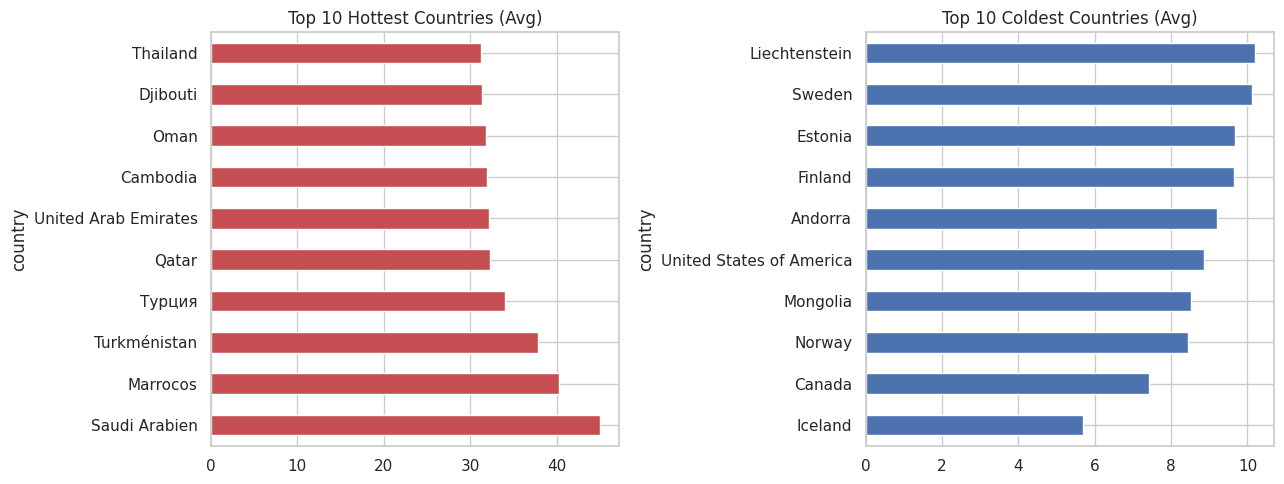

In [59]:
# --- 6e (cont.) Hottest / coldest countries on average ---
hottest = df_clean.groupby(COL["country"])[COL["temp_c"]].mean().sort_values(ascending=False).head(10)
coldest = df_clean.groupby(COL["country"])[COL["temp_c"]].mean().sort_values().head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
hottest.plot(kind="barh", ax=axes[0], color="#C44E52", title="Top 10 Hottest Countries (Avg)")
coldest.plot(kind="barh", ax=axes[1], color="#4C72B0", title="Top 10 Coldest Countries (Avg)")
plt.tight_layout()
plt.show()

In [60]:
requirements_txt = """pandas
numpy
matplotlib
seaborn
scikit-learn
statsmodels
xgboost
prophet
shap
plotly
folium
pycountry_convert
scipy
"""
with open("requirements.txt", "w") as f:
    f.write(requirements_txt)
print(requirements_txt)

pandas
numpy
matplotlib
seaborn
scikit-learn
statsmodels
xgboost
prophet
shap
plotly
folium
pycountry_convert
scipy



In [61]:
readme_md = """# Weather Trend Forecasting — Global Weather Repository

## PM Accelerator Mission
[Paste the exact, current mission statement copied from https://www.pmaccelerator.io/ here.]

## Project Overview
This project analyzes the Global Weather Repository dataset to uncover trends and forecast
short-term weather conditions, combining classical time-series models, gradient-boosted
trees, and an ensemble, alongside anomaly detection and spatial/feature analyses.

## Methodology
1. Data Cleaning & Preprocessing — missing values (location-aware median imputation),
   outliers (IQR winsorization), normalization (z-score scaling).
2. Exploratory Data Analysis — distributions, correlation structure, temperature/precipitation
   trend visualization.
3. Basic Forecasting Model — lag/rolling-feature Linear Regression vs naive persistence baseline,
   evaluated with MAE / RMSE / MAPE / R-squared.
4. Advanced EDA — Isolation Forest + z-score multivariate anomaly detection.
5. Multi-Model Forecasting & Ensemble — SARIMA, Prophet, XGBoost, combined via an
   inverse-RMSE-weighted ensemble.
6. Unique Analyses — climate patterns by country/month, air-quality vs weather correlation,
   Random Forest / permutation / SHAP feature importance, spatial heatmaps, continent-level
   geographic comparison.

## Results Summary
(Insert the `results_df` table from Section 5 here — model name, MAE, RMSE, MAPE, R-squared.)

## How to Run
1. `pip install -r requirements.txt`
2. Place `GlobalWeatherRepository.csv` in the working directory (or use the Kaggle
   `/kaggle/input/...` path auto-detected by the notebook).
3. Run all cells top to bottom.

## Repository Structure
.
notebook.ipynb        # this analysis
requirements.txt
README.md
temperature_heatmap.html   # exported interactive spatial view

## Demo Video
[Insert viewable link to a 1-2 minute screen-recorded walkthrough of code + results.]
"""
with open("README.md", "w") as f:
    f.write(readme_md)
print("README.md and requirements.txt written to the working directory.")

README.md and requirements.txt written to the working directory.


In [ ]:
# Weather Trend Forecasting — Global Weather Repository
### Technical Assessment for Data Scientist / Analyst — PM Accelerator

**Objective:** Analyze the *Global Weather Repository* dataset to forecast weather trends, demonstrating both basic and advanced data science techniques — cleaning, EDA, forecasting, anomaly detection, model ensembling, and spatial / feature analysis.

This notebook mirrors the assessment brief section-by-section so every requirement maps to a runnable cell.

| # | Section | Maps to assessment requirement |
|---|---|---|
| 0 | Setup, data load, PM Accelerator mission | Deliverable |
| 1 | Data Cleaning & Preprocessing | Basic |
| 2 | Exploratory Data Analysis | Basic |
| 3 | Basic Forecasting Model | Basic |
| 4 | Advanced EDA — Anomaly Detection | Advanced |
| 5 | Multi-Model Forecasting + Ensemble | Advanced |
| 6 | Unique Analyses (Climate, Air Quality, Feature Importance, Spatial, Geographic) | Advanced |
| 7 | Deliverable helpers (README, requirements.txt) | Deliverable |

> Run cells top to bottom. Each section is self-contained but depends on `df_clean` and the `COL` column-mapping dictionary created in Section 0.
